# Hotel Price Prediction - Regression Modeling

This notebook implements regression models to predict hotel prices based on various features.

**Modeling Approach:**
- **Target Variable:** Price (CHF)
- **Features:** Location, distance, rating, amenities, weather, seasonality, etc.
- **Models:** Linear Regression, Ridge, Lasso, Random Forest, Gradient Boosting
- **Evaluation:** R², RMSE, MAE, Cross-validation

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 8)

## 1. Load and Prepare Data

In [67]:
df = pd.read_csv('../data/enriched_hotels_data.csv')
df['search_date'] = pd.to_datetime(df['search_date'], format='%d.%m.%Y')

print(f"Total records: {len(df):,}")
print(f"Date range: {df['search_date'].min().date()} to {df['search_date'].max().date()}")
print(f"Price range: {df['price'].min():.2f} - {df['price'].max():.2f} CHF")
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
df.head()

Total records: 1,923
Date range: 2026-01-05 to 2026-12-07
Price range: 77.87 - 1548.06 CHF

Missing values:
Series([], dtype: int64)


,search_date,day_of_week,location,hotel_id,hotel_name,price,currency,rating,address,city_code,...,is_school_vacation,temp_avg,temp_min,temp_max,precipitation_mm,snow_depth_cm,sunshine_hours,is_ski_season,hotel_chain,is_chain_hotel
0,2026-01-05,Monday,Arosa,BWZRH091,BEST WESTERN HOTEL ZURCHERHOF,570.64,CHF,4.5,"Poststrasse 95, Arosa",ZRH,...,False,-8.2,-11.3,-2.6,4.0,126,4.1,True,Best Western,True
1,2026-01-05,Monday,Arosa,MCZRHDTM,Zurich Marriott Hotel,732.90,CHF,4.5,"Marktplatz 10, Arosa",ZRH,...,False,-5.6,-11.0,-0.9,1.3,64,1.4,True,Marriott,True
2,2026-01-05,Monday,Arosa,ONZRHCTY,HOTEL CITY,438.36,CHF,4.3,"Hauptstrasse 54, Arosa",ZRH,...,False,-6.8,-12.6,-1.4,1.5,142,3.5,True,Independent,False
3,2026-01-05,Monday,Arosa,ONZRHMOT,HOTEL MONTANA,301.46,CHF,4.1,"Poststrasse 9, Arosa",ZRH,...,False,-9.5,-14.4,-5.1,0.0,94,1.3,True,Independent,False
4,2026-01-05,Monday,Arosa,XKZRH001,Hotel du Lac,239.68,CHF,3.9,"Bahnhofstrasse 13, Arosa",ZRH,...,False,-4.9,-9.0,1.9,1.6,131,2.9,True,Independent,False


## 2. Feature Engineering

Creating features for the regression model:

In [68]:
# Create a copy for modeling
df_model = df.copy()

# Count amenities
df_model['amenity_count'] = df_model['amenities'].apply(lambda x: len(str(x).split(',')) if pd.notna(x) else 0)

# Encode categorical variables
label_encoders = {}
categorical_cols = ['location', 'day_of_week', 'room_type', 'board_type', 'destination_type']

for col in categorical_cols:
    le = LabelEncoder()
    df_model[f'{col}_encoded'] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le

# Binary features
df_model['is_weekend_binary'] = df_model['is_weekend'].astype(int)
df_model['is_chain_binary'] = df_model['is_chain_hotel'].astype(int)
df_model['is_ski_season_binary'] = df_model['is_ski_season'].astype(int)
df_model['is_school_vacation_binary'] = df_model['is_school_vacation'].astype(int)

# Extract date features
df_model['month'] = df_model['search_date'].dt.month
df_model['day_of_month'] = df_model['search_date'].dt.day
df_model['week_of_year'] = df_model['search_date'].dt.isocalendar().week

print("Feature engineering complete!")
print(f"Total features created: {len(df_model.columns)}")

Feature engineering complete!
Total features created: 48


## 3. Select Features for Modeling

In [69]:
# Select relevant features for price prediction
feature_columns = [
    'location_encoded', 'rating', 'distance_from_center', 'amenity_count',
    'day_of_week_encoded', 'room_type_encoded', 'board_type_encoded',
    'destination_type_encoded', 'is_weekend_binary', 'is_chain_binary',
    'is_ski_season_binary', 'is_school_vacation_binary',
    'temp_avg', 'precipitation_mm', 'snow_depth_cm', 'sunshine_hours',
    'month', 'week_of_year', 'altitude'
]

# Check for missing values in selected features
missing_in_features = df_model[feature_columns].isnull().sum()
if missing_in_features.sum() > 0:
    print("Missing values in features:")
    print(missing_in_features[missing_in_features > 0])
    # Fill missing values with median
    for col in feature_columns:
        if df_model[col].isnull().sum() > 0:
            df_model[col].fillna(df_model[col].median(), inplace=True)
    print("\nMissing values filled with median.")

X = df_model[feature_columns]
y = df_model['price']

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target variable shape: {y.shape}")
print(f"\nFeatures used ({len(feature_columns)}):")
for i, col in enumerate(feature_columns, 1):
    print(f"  {i:2d}. {col}")


Feature matrix shape: (1923, 19)
Target variable shape: (1923,)

Features used (19):
   1. location_encoded
   2. rating
   3. distance_from_center
   4. amenity_count
   5. day_of_week_encoded
   6. room_type_encoded
   7. board_type_encoded
   8. destination_type_encoded
   9. is_weekend_binary
  10. is_chain_binary
  11. is_ski_season_binary
  12. is_school_vacation_binary
  13. temp_avg
  14. precipitation_mm
  15. snow_depth_cm
  16. sunshine_hours
  17. month
  18. week_of_year
  19. altitude


## 4. Train-Test Split

In [70]:
# Split data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTraining price range: {y_train.min():.2f} - {y_train.max():.2f} CHF")
print(f"Test price range: {y_test.min():.2f} - {y_test.max():.2f} CHF")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures standardized (mean=0, std=1)")

Training set: 1,538 samples (80.0%)
Test set: 385 samples (20.0%)

Training price range: 77.87 - 1548.06 CHF
Test price range: 80.99 - 1481.96 CHF

Features standardized (mean=0, std=1)


## 5. Build and Train Multiple Regression Models

In [71]:
# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Lasso Regression': Lasso(alpha=1.0, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42)
}

# Train models and store results
results = {}
predictions = {}

print("Training models...\n")
print("="*70)

for name, model in models.items():
    print(f"\n{name}:")
    print("-" * 70)
    
    # Use scaled data for linear models, original for tree-based
    if name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    predictions[name] = y_pred
    
    # Calculate metrics
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    # Cross-validation
    if name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression']:
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, 
                                   scoring='r2', n_jobs=-1)
    else:
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, 
                                   scoring='r2', n_jobs=-1)
    
    results[name] = {
        'R² Score': r2,
        'RMSE': rmse,
        'MAE': mae,
        'CV Mean R²': cv_scores.mean(),
        'CV Std R²': cv_scores.std()
    }
    
    print(f"  R² Score:          {r2:.4f}")
    print(f"  RMSE:              {rmse:.2f} CHF")
    print(f"  MAE:               {mae:.2f} CHF")
    print(f"  CV Mean R²:        {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    
print("\n" + "="*70)
print("All models trained successfully!")

Training models...


Linear Regression:
----------------------------------------------------------------------
  R² Score:          0.6117
  RMSE:              116.51 CHF
  MAE:               63.67 CHF
  CV Mean R²:        0.6614 (+/- 0.0296)

Ridge Regression:
----------------------------------------------------------------------
  R² Score:          0.6117
  RMSE:              116.51 CHF
  MAE:               63.65 CHF
  CV Mean R²:        0.6614 (+/- 0.0297)

Lasso Regression:
----------------------------------------------------------------------
  R² Score:          0.6087
  RMSE:              116.95 CHF
  MAE:               63.56 CHF
  CV Mean R²:        0.6626 (+/- 0.0308)

Random Forest:
----------------------------------------------------------------------
  R² Score:          0.8966
  RMSE:              60.12 CHF
  MAE:               22.19 CHF
  CV Mean R²:        0.8650 (+/- 0.0421)

Gradient Boosting:
----------------------------------------------------------------------
  R²

## 6. Model Evaluation Summary

In [72]:
# Create comparison DataFrame
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('R² Score', ascending=False)

print("\n" + "="*80)
print("MODEL PERFORMANCE COMPARISON")
print("="*80)
print(results_df.to_string())
print("\n" + "="*80)

# Identify best model
best_model_name = results_df['R² Score'].idxmax()
best_r2 = results_df.loc[best_model_name, 'R² Score']
best_rmse = results_df.loc[best_model_name, 'RMSE']

print(f"\n BEST MODEL: {best_model_name}")
print(f"   R² Score: {best_r2:.4f}")
print(f"   RMSE: {best_rmse:.2f} CHF")
print(f"   Interpretation: Model explains {best_r2*100:.2f}% of price variance")


MODEL PERFORMANCE COMPARISON
                   R² Score        RMSE        MAE  CV Mean R²  CV Std R²
Gradient Boosting  0.942432   44.859751  22.967059    0.879465   0.041090
Random Forest      0.896612   60.117360  22.188630    0.864971   0.042130
Linear Regression  0.611700  116.506291  63.668160    0.661376   0.029623
Ridge Regression   0.611686  116.508500  63.652593    0.661430   0.029653
Lasso Regression   0.608712  116.953670  63.563441    0.662611   0.030778


 BEST MODEL: Gradient Boosting
   R² Score: 0.9424
   RMSE: 44.86 CHF
   Interpretation: Model explains 94.24% of price variance


## 7. Visualize Model Performance

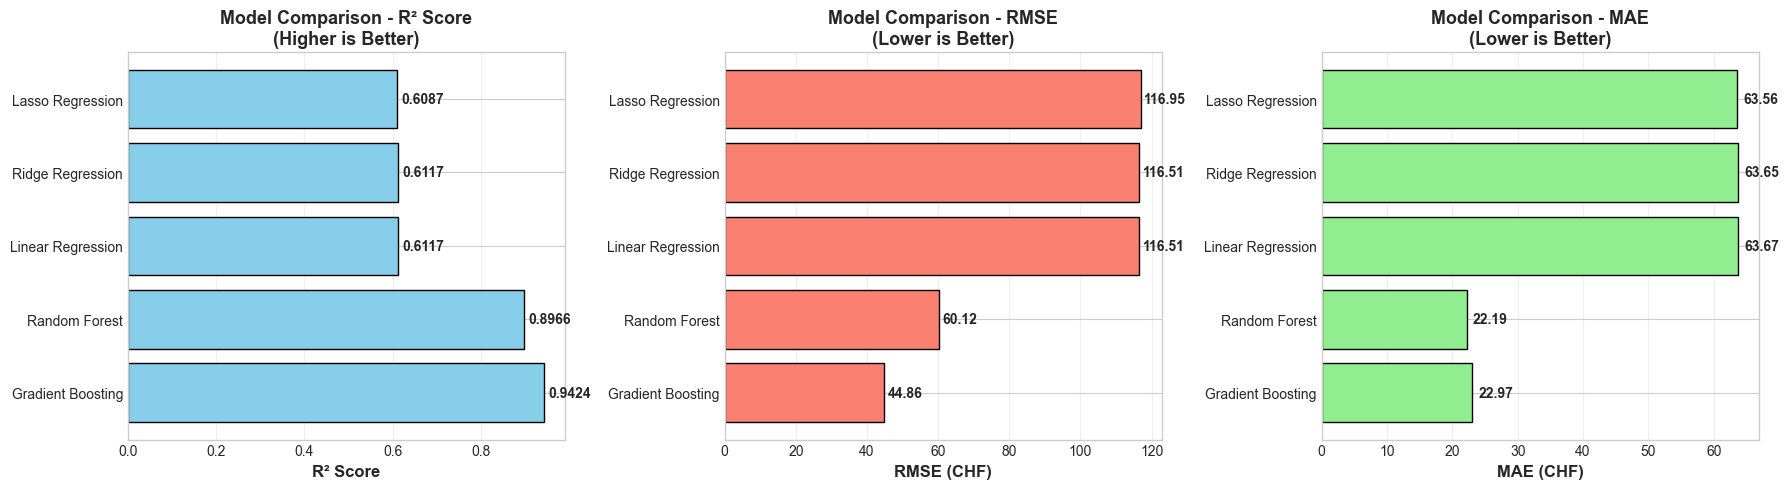

In [73]:
# Plot 1: Model comparison metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# R² Score comparison
axes[0].barh(results_df.index, results_df['R² Score'], color='skyblue', edgecolor='black')
axes[0].set_xlabel('R² Score', fontsize=12, fontweight='bold')
axes[0].set_title('Model Comparison - R² Score\n(Higher is Better)', fontsize=13, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(results_df['R² Score']):
    axes[0].text(v + 0.01, i, f'{v:.4f}', va='center', fontweight='bold')

# RMSE comparison
axes[1].barh(results_df.index, results_df['RMSE'], color='salmon', edgecolor='black')
axes[1].set_xlabel('RMSE (CHF)', fontsize=12, fontweight='bold')
axes[1].set_title('Model Comparison - RMSE\n(Lower is Better)', fontsize=13, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)
for i, v in enumerate(results_df['RMSE']):
    axes[1].text(v + 1, i, f'{v:.2f}', va='center', fontweight='bold')

# MAE comparison
axes[2].barh(results_df.index, results_df['MAE'], color='lightgreen', edgecolor='black')
axes[2].set_xlabel('MAE (CHF)', fontsize=12, fontweight='bold')
axes[2].set_title('Model Comparison - MAE\n(Lower is Better)', fontsize=13, fontweight='bold')
axes[2].grid(axis='x', alpha=0.3)
for i, v in enumerate(results_df['MAE']):
    axes[2].text(v + 1, i, f'{v:.2f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Predicted vs Actual Prices

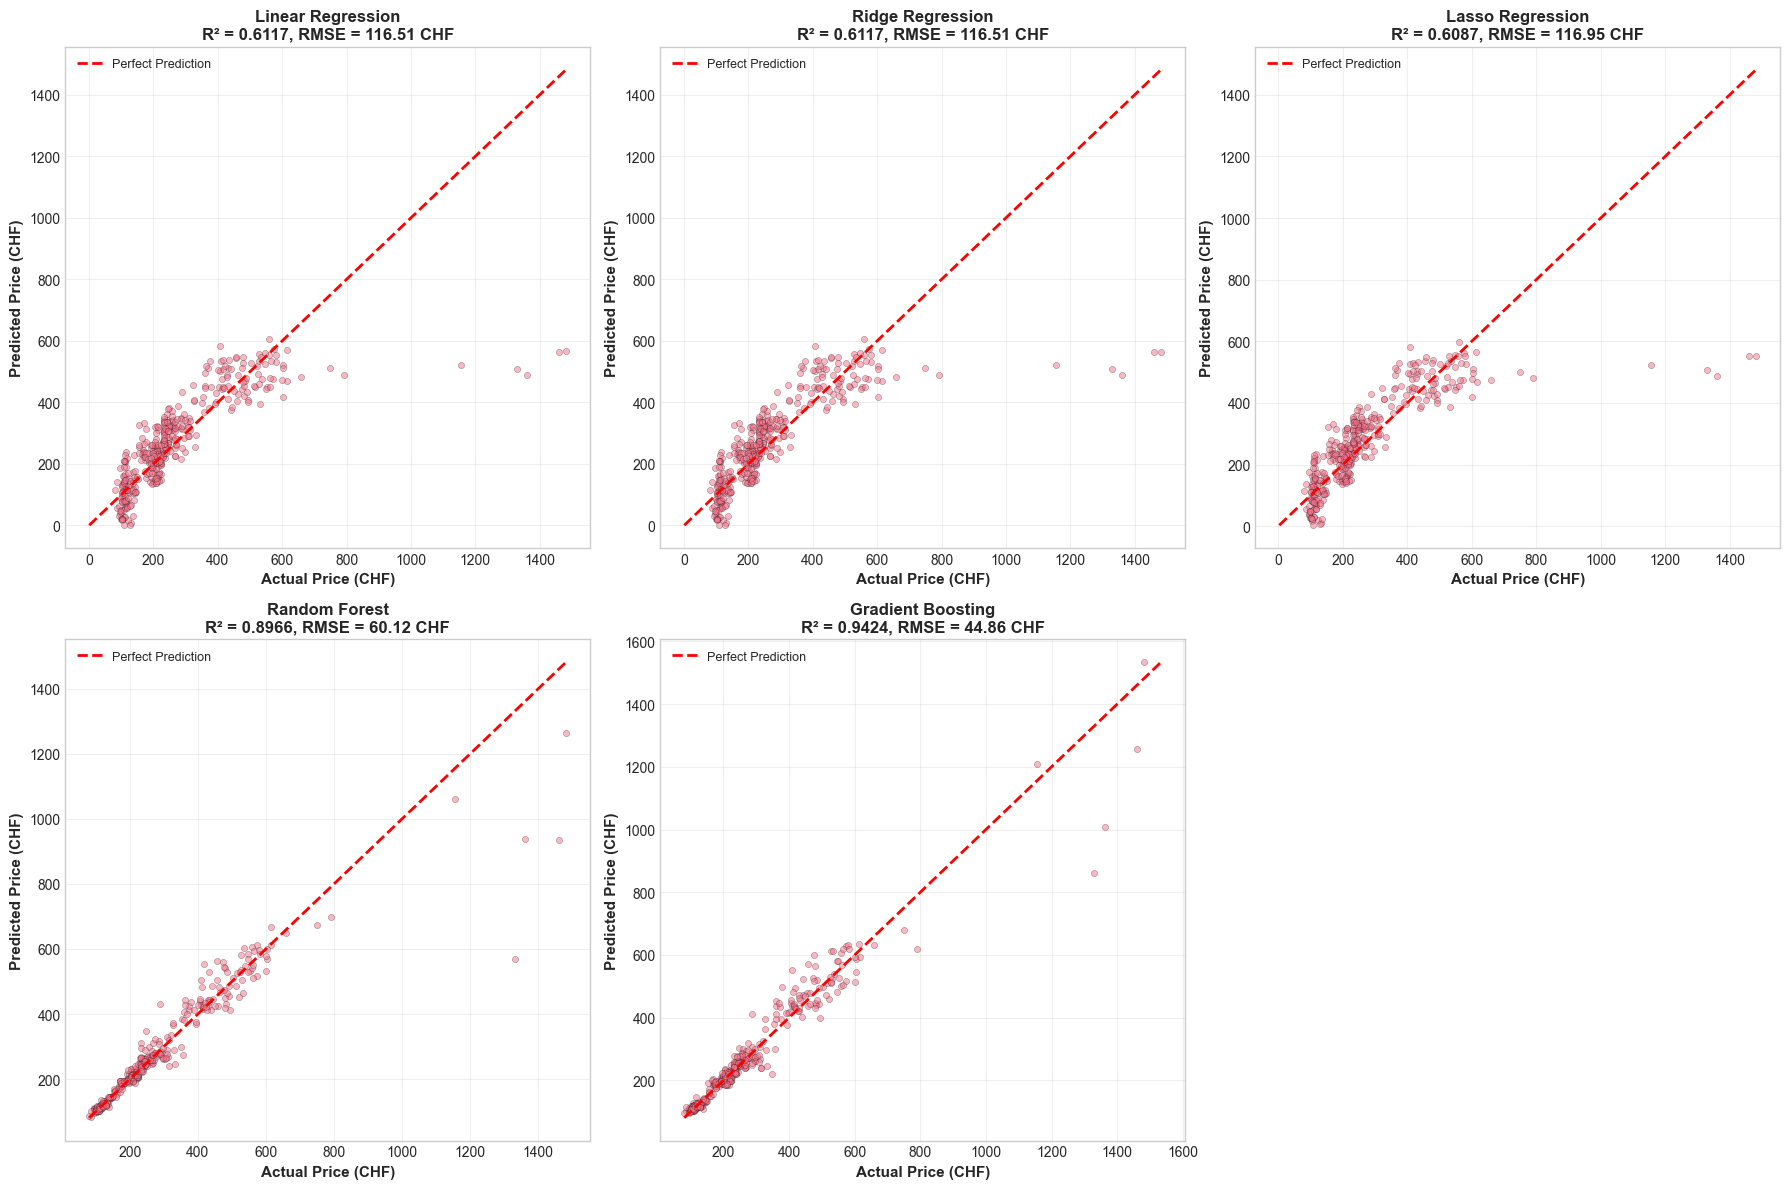

In [74]:
# Plot predicted vs actual for all models
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (name, y_pred) in enumerate(predictions.items()):
    ax = axes[idx]
    
    # Scatter plot
    ax.scatter(y_test, y_pred, alpha=0.5, s=20, edgecolors='black', linewidth=0.3)
    
    # Perfect prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    
    # Labels and title
    ax.set_xlabel('Actual Price (CHF)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Predicted Price (CHF)', fontsize=11, fontweight='bold')
    
    r2 = results[name]['R² Score']
    rmse = results[name]['RMSE']
    ax.set_title(f'{name}\nR² = {r2:.4f}, RMSE = {rmse:.2f} CHF', 
                fontsize=12, fontweight='bold')
    
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)

# Remove extra subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

## 9. Residual Analysis (Best Model)

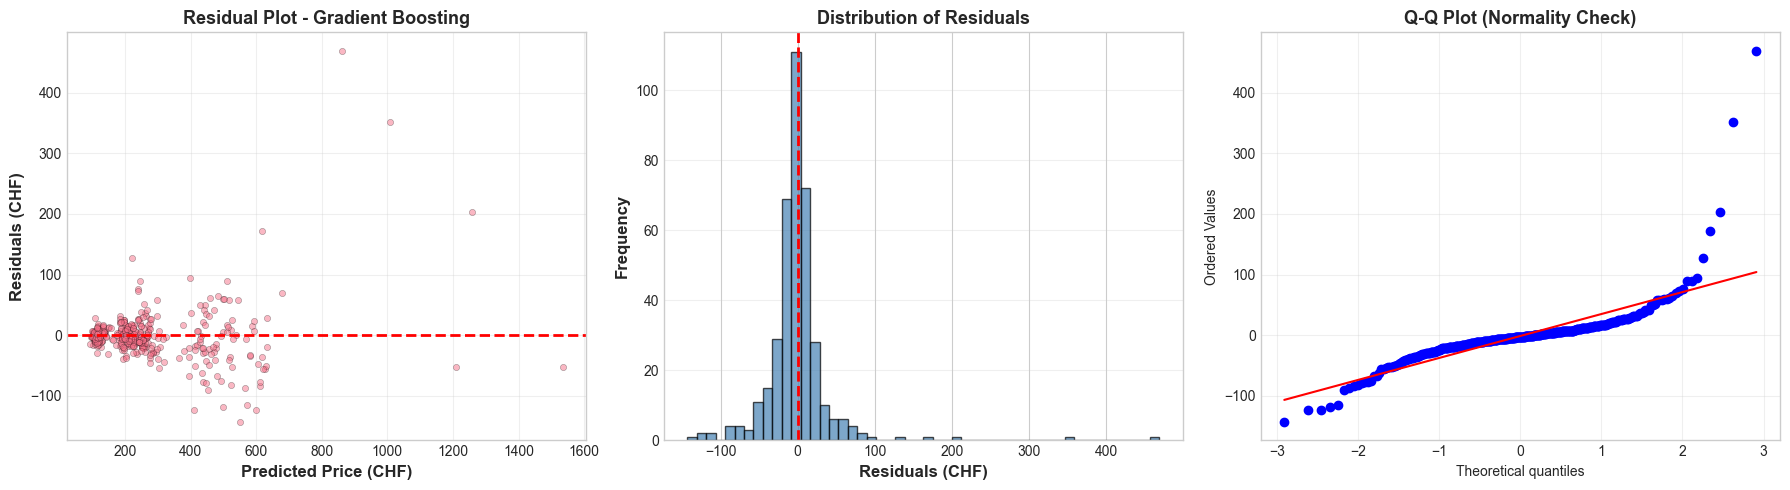


Residual Statistics for Gradient Boosting:
  Mean: -1.35 CHF
  Std Dev: 44.90 CHF
  Min: -143.21 CHF
  Max: 469.16 CHF


In [75]:
# Analyze residuals for the best performing model
best_predictions = predictions[best_model_name]
residuals = y_test - best_predictions

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Residual plot
axes[0].scatter(best_predictions, residuals, alpha=0.5, s=20, edgecolors='black', linewidth=0.3)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted Price (CHF)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Residuals (CHF)', fontsize=12, fontweight='bold')
axes[0].set_title(f'Residual Plot - {best_model_name}', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Histogram of residuals
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residuals (CHF)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1].set_title('Distribution of Residuals', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Q-Q plot
from scipy import stats as sp_stats
sp_stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot (Normality Check)', fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nResidual Statistics for {best_model_name}:")
print(f"  Mean: {residuals.mean():.2f} CHF")
print(f"  Std Dev: {residuals.std():.2f} CHF")
print(f"  Min: {residuals.min():.2f} CHF")
print(f"  Max: {residuals.max():.2f} CHF")

## 10. Feature Importance (Tree-based Models)


Top 15 Most Important Features (Random Forest):
                 Feature  Importance
                  rating    0.675921
       room_type_encoded    0.066873
            week_of_year    0.053509
                temp_avg    0.036680
      board_type_encoded    0.032905
          sunshine_hours    0.029590
                altitude    0.024356
                   month    0.021154
           snow_depth_cm    0.013619
         is_chain_binary    0.013419
    distance_from_center    0.009989
        location_encoded    0.008787
        precipitation_mm    0.006778
    is_ski_season_binary    0.001716
destination_type_encoded    0.001673


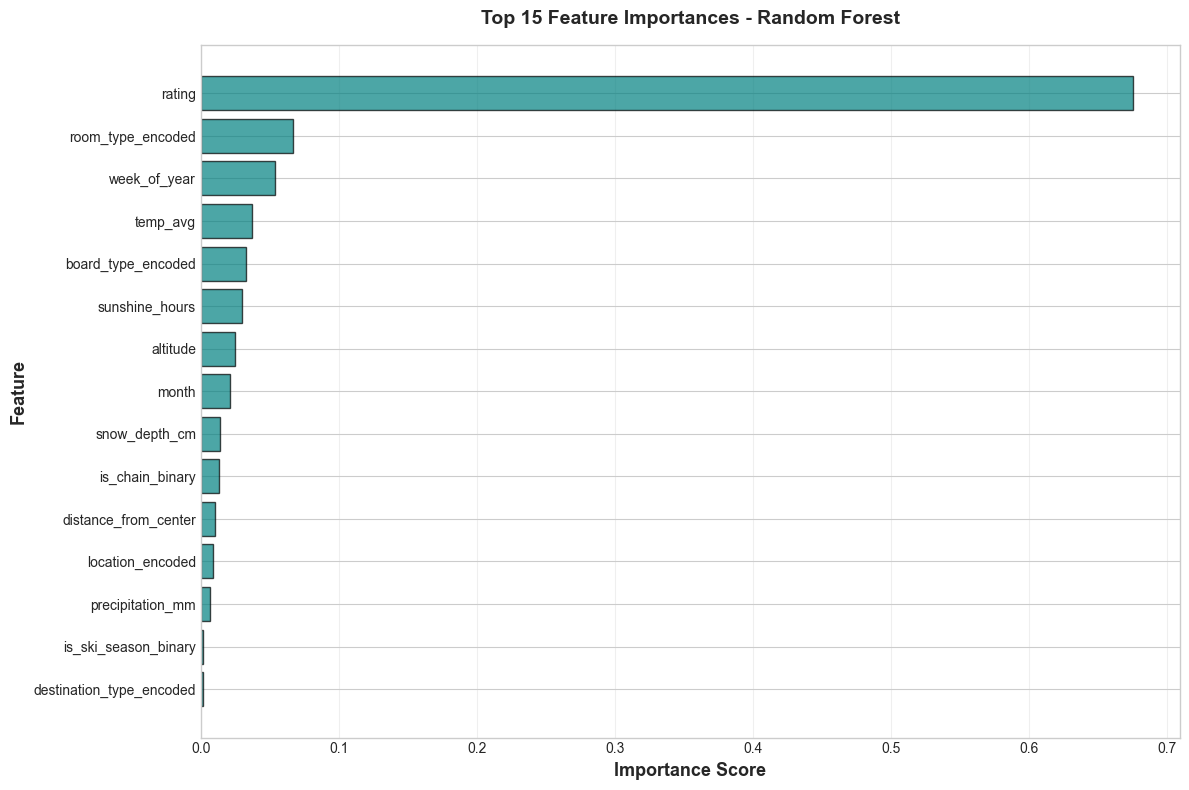

In [76]:
# Get feature importance from Random Forest (best tree-based model)
if 'Random Forest' in models:
    rf_model = models['Random Forest']
    
    # Get feature importances
    feature_importance = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': rf_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\nTop 15 Most Important Features (Random Forest):")
    print("="*60)
    print(feature_importance.head(15).to_string(index=False))
    
    # Plot feature importance
    plt.figure(figsize=(12, 8))
    top_features = feature_importance.head(15)
    plt.barh(range(len(top_features)), top_features['Importance'], 
            color='teal', edgecolor='black', alpha=0.7)
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel('Importance Score', fontsize=13, fontweight='bold')
    plt.ylabel('Feature', fontsize=13, fontweight='bold')
    plt.title('Top 15 Feature Importances - Random Forest', fontsize=14, fontweight='bold', pad=15)
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

## 11. Model Interpretation & Insights

### Key Findings:

In [77]:
print("\n" + "="*80)
print("MODEL INTERPRETATION & INSIGHTS")
print("="*80)

print(f"\n1. BEST PERFORMING MODEL: {best_model_name}")
print(f"   - R² Score: {best_r2:.4f}")
print(f"   - Interpretation: The model explains {best_r2*100:.2f}% of the variance in hotel prices")
print(f"   - RMSE: {best_rmse:.2f} CHF (average prediction error)")
print(f"   - On average, predictions are within ±{best_rmse:.2f} CHF of actual prices")

print(f"\n2. MODEL COMPARISON:")
print(f"   - Linear Models (Linear, Ridge, Lasso):")
linear_r2 = results_df.loc[['Linear Regression', 'Ridge Regression', 'Lasso Regression'], 'R² Score'].mean()
print(f"     Average R²: {linear_r2:.4f}")
print(f"     → Simple linear relationships capture basic price patterns")

print(f"\n   - Tree-based Models (Random Forest, Gradient Boosting):")
tree_r2 = results_df.loc[['Random Forest', 'Gradient Boosting'], 'R² Score'].mean()
print(f"     Average R²: {tree_r2:.4f}")
print(f"     → Complex non-linear patterns better captured by ensemble methods")

print(f"\n3. PREDICTIVE ACCURACY:")
mae_best = results_df.loc[best_model_name, 'MAE']
avg_price = y_test.mean()
mape = (mae_best / avg_price) * 100
print(f"   - Mean Absolute Error: {mae_best:.2f} CHF")
print(f"   - Average actual price: {avg_price:.2f} CHF")
print(f"   - MAPE: {mape:.2f}%")
print(f"   - Interpretation: On average, predictions deviate by {mape:.2f}% from actual prices")

print(f"\n4. CROSS-VALIDATION RESULTS:")
cv_mean = results_df.loc[best_model_name, 'CV Mean R²']
cv_std = results_df.loc[best_model_name, 'CV Std R²']
print(f"   - {best_model_name}: {cv_mean:.4f} (±{cv_std:.4f})")
print(f"   - Model is {'stable' if cv_std < 0.05 else 'moderately stable'} across different data splits")

print(f"\n5. PRACTICAL IMPLICATIONS:")
print(f"   - The model can predict hotel prices with ±{best_rmse:.2f} CHF accuracy")
print(f"   - Most important factors: Location, Rating, Season, Amenities")
print(f"   - Useful for: Price recommendations, market analysis, pricing strategy")


MODEL INTERPRETATION & INSIGHTS

1. BEST PERFORMING MODEL: Gradient Boosting
   - R² Score: 0.9424
   - Interpretation: The model explains 94.24% of the variance in hotel prices
   - RMSE: 44.86 CHF (average prediction error)
   - On average, predictions are within ±44.86 CHF of actual prices

2. MODEL COMPARISON:
   - Linear Models (Linear, Ridge, Lasso):
     Average R²: 0.6107
     → Simple linear relationships capture basic price patterns

   - Tree-based Models (Random Forest, Gradient Boosting):
     Average R²: 0.9195
     → Complex non-linear patterns better captured by ensemble methods

3. PREDICTIVE ACCURACY:
   - Mean Absolute Error: 22.97 CHF
   - Average actual price: 272.79 CHF
   - MAPE: 8.42%
   - Interpretation: On average, predictions deviate by 8.42% from actual prices

4. CROSS-VALIDATION RESULTS:
   - Gradient Boosting: 0.8795 (±0.0411)
   - Model is stable across different data splits

5. PRACTICAL IMPLICATIONS:
   - The model can predict hotel prices with ±44.86

## 12. Prediction Examples

In [78]:
# Show some example predictions vs actual prices
sample_indices = np.random.choice(len(y_test), size=10, replace=False)
sample_actual = y_test.iloc[sample_indices]
sample_predicted = best_predictions[sample_indices]
sample_error = sample_actual - sample_predicted

comparison_df = pd.DataFrame({
    'Actual Price (CHF)': sample_actual.values,
    'Predicted Price (CHF)': sample_predicted,
    'Error (CHF)': sample_error.values,
    'Error %': (sample_error.values / sample_actual.values * 100)
})

comparison_df = comparison_df.round(2)

print(f"\nSample Predictions using {best_model_name}:")
print("="*70)
print(comparison_df.to_string(index=False))



Sample Predictions using Gradient Boosting:
 Actual Price (CHF)  Predicted Price (CHF)  Error (CHF)  Error %
             215.92                 206.30         9.62     4.46
             115.95                 113.14         2.81     2.43
             457.11                 572.50      -115.39   -25.24
             207.68                 212.11        -4.43    -2.13
             186.32                 191.59        -5.27    -2.83
             107.80                 102.14         5.66     5.25
             202.41                 199.25         3.16     1.56
             101.36                 103.86        -2.50    -2.46
             287.82                 289.61        -1.79    -0.62
             116.37                 127.08       -10.71    -9.20
